<a href="https://colab.research.google.com/github/diopmax25/OD/blob/main/Copie_de_EXO_GEOAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

In [ ]:
!git --version

git version 2.34.1


In [ ]:
!git clone https://github.com/geoaiclassroom/geoai_learning.git

Cloning into 'geoai_learning'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 68 (delta 26), reused 54 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 6.80 MiB | 22.90 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [ ]:
%cd geoai_learning

/content/geoai_learning/Tutorial3/geoai_learning


In [ ]:
%cd Tutorial3

/content/geoai_learning/Tutorial3/geoai_learning/Tutorial3


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size = (32,32)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
images = []
images.append(Image.open('/content/sample_data/curiosidades-viajar-avion.jpeg'))
images.append(Image.open('/content/sample_data/istockphoto-535895109-612x612.jpg'))

### Lister les fichiers dans le répertoire actuel

Cela vous aidera à trouver les noms exacts des images que vous avez téléchargées.

In [ ]:
!ls

Assets	CNN.ipynb  model_augmented.pt  sample1.jpg  sample2.jpg


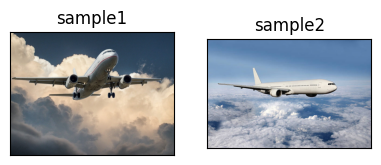

In [ ]:
# create a plot figure
fig = plt.figure(figsize=(25, 4))
# display each image using a for-loop
for idx in range(len(images)):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    plt.imshow(images[idx])
    ax.set_title('sample'+str(idx + 1))

In [ ]:
 # define the CNN model's architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Input depth, Output depth, Kernel Size (padding=1 means the Same padding where the output layer has the same size as the input layer).
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 4 * 4, 500)
        self.fc2 = nn.Linear(500, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # add sequence of convolutional and max pooling layers
        x = self.pool(F.relu(self.conv1(x)))  # receives 32x32x3 input, return 16x16x16 output
        x = self.pool(F.relu(self.conv2(x)))  # returns 8x8x32 tensor
        x = self.pool(F.relu(self.conv3(x)))  # return 4x4x64 tensor
        # flatten image input
        x = x.view(-1, 64 * 4 * 4) # returns a 64*4*4-d vector
        # add dropout layer
        x = self.dropout(x)
        # add 1st hidden layer, with relu activation function
        x = F.relu(self.fc1(x))  # outputs a 500-d vector
        # add dropout layer
        x = self.dropout(x)
        # add 2nd hidden layer, with relu activation function
        x = self.fc2(x)  # outputs a 10-d vector
        return x

# create a CNN object
model = Net()

In [ ]:
# loads the trained model and bring it to evaluation/inference (non-training) mode!
model.load_state_dict(torch.load('model_augmented.pt', map_location=torch.device('cpu'), weights_only=True))
model.eval()

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

In [ ]:
# Let's feed the images to the model and see the output

predicted_classes = []
for idx in range(len(images)):
    #first transform the image in the way that the model expects it as input
    img = transform(images[idx])
    # forward pass: compute predicted outputs by passing inputs to the model
    output_scores = model(img)
    # convert output probabilities to predicted class (highest score)
    _, pred_tensor = torch.max(output_scores, 1)
    pred = np.squeeze(pred_tensor.numpy())
    predicted_classes.append(classes[pred])
    print("sample {}".format(idx))
    print("\t Predicted scores: ", np.around(output_scores.detach().numpy()[0,:], 2))
    print("\t Predicted class: ", classes[pred])

sample 0
	 Predicted scores:  [ 3.49 -2.19  1.15 -0.24  2.05  0.47 -3.19  0.15  0.76 -2.08]
	 Predicted class:  airplane
sample 1
	 Predicted scores:  [ 6.12 -1.27  0.28 -1.89  0.05 -2.81 -2.34 -2.93  3.87  0.7 ]
	 Predicted class:  airplane


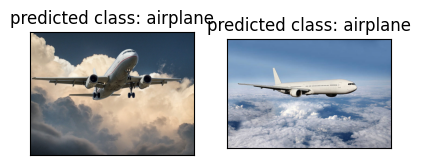

In [ ]:
# create a plot figure
fig = plt.figure(figsize=(25, 4))
# show each image and the predicted class as its title
for idx in range(len(images)):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    # display the images
    plt.imshow(images[idx])
    # add title with the predicted class
    ax.set_title('predicted class: {}'.format(predicted_classes[idx]))